Mean: 4.965
Variance: 0.168
Standard Deviation: 0.410


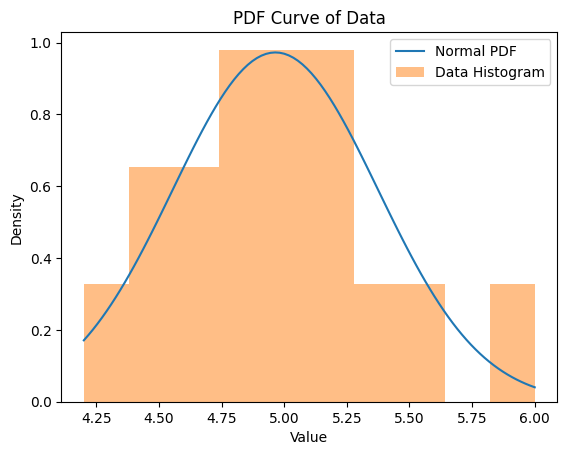

In [4]:
import numpy as np

import matplotlib.pyplot as plt

data = [5, 5.5, 5.2, 4.5, 4.9, 4.9, 4.8, 4.7, 4.6, 4.5, 5.0, 6, 5.1, 5.2, 5.3, 5, 4.2]
mean = sum(data) / len(data)
print(f"Mean: {mean:.3f}")
variance = sum((x - mean) ** 2 for x in data) / len(data)
print(f"Variance: {variance:.3f}")
standard_deviation = variance ** 0.5
print(f"Standard Deviation: {standard_deviation:.3f}")


# Generate values for the x-axis
x = np.linspace(min(data), max(data), 100)
# Calculate the PDF of a normal distribution with the computed mean and std dev
pdf = (1 / (standard_deviation * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / standard_deviation) ** 2)

plt.plot(x, pdf, label='Normal PDF')
plt.hist(data, bins=10, density=True, alpha=0.5, label='Data Histogram')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('PDF Curve of Data')
plt.legend()
plt.show()

In [13]:
from scipy.stats import norm
from scipy import integrate

bad_data = [4.546, 4.5, 4.567, 4.508, 4.602, 4.504, 4.666, 4.662, 4.624, 4.518, 4.743, 4.748, 4.775, 4.627, 4.642, 4.747, 4.566, 4.551, 4.536, 4.622, 4.676, 4.557, 4.733, 4.532, 4.667, 4.732, 4.634, 4.7, 4.764, 4.602, 4.644, 4.77, 4.624, 4.717, 4.538, 4.502, 4.798, 4.772, 4.537, 4.586, 4.543, 4.563, 4.675, 4.713, 4.509, 4.678, 4.729, 4.782, 4.722, 4.579]
lidar_data = []
for i in bad_data:
    lidar_data.append(i + 0.36)

mean_lidar = sum(lidar_data) / len(lidar_data)
std_lidar = (sum((x - mean_lidar) ** 2 for x in lidar_data) / len(lidar_data)) ** 0.5

# Probability density function for the normal distribution
pdf_lidar = lambda x: norm.pdf(x, loc=mean_lidar, scale=std_lidar)

# Integrate from 4.9 to 5.1
prob, _ = integrate.quad(pdf_lidar, 4.9, 5.1)
print(f"P(4.9 ≤ X ≤ 5.1) ≈ {prob}")

#####################################################################3

# Find a such that P(a < X < mean) is a given value
prob_range = 0.45
from scipy.optimize import fsolve
def prob_between_a_and_mean(a):
    return norm.cdf(mean_lidar, loc=mean_lidar, scale=std_lidar) - norm.cdf(a, loc=mean_lidar, scale=std_lidar) - prob_range
a_solution = fsolve(prob_between_a_and_mean, mean_lidar - std_lidar)[0]
print(f"Value of a such that P(a < X < mean) = {prob_range}: {a_solution:.2f}")


P(4.9 ≤ X ≤ 5.1) ≈ 0.7307058582237324
Value of a such that P(a < X < mean) = 0.45: 4.85
